## Midterm PGE 379/383 Well Testing
Daniel McAllister-Ou

---
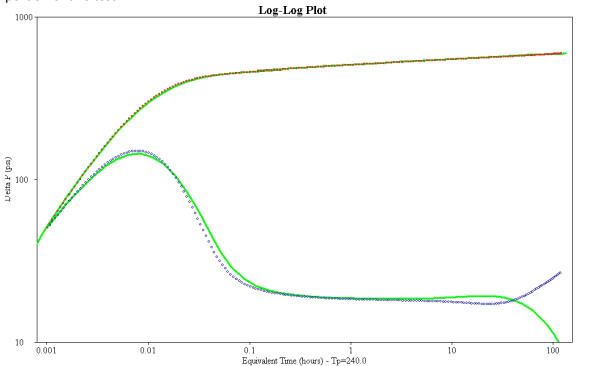

1. Each point on the upper curve represents:  
a. The difference in pressure between the initial pressure and the current pressure.  
b. The difference in pressure between the current pressure and the last flowing pressure.  
c. Neither a nor b  


2. Each point on the lower curves represents:  
a. The derivative of current pressure with respect to time that the well has been shut-in  
b. The derivative of current pressure w.r.t. log time that the well has been shut in  
c. The derivative of current pressure w.r.t. square root of time that the well has been shut-in  
d. The derivative of current pressure w.r.t. inverse square root of time that the well has been shut-in.  

1. Each point on the upper curve represents b. The difference between the current pressure and the last flowing pressure  
2. Each point on the lowe curve represents b. The derivative of current pressure w.r.t. log time that the well has been shut in

---

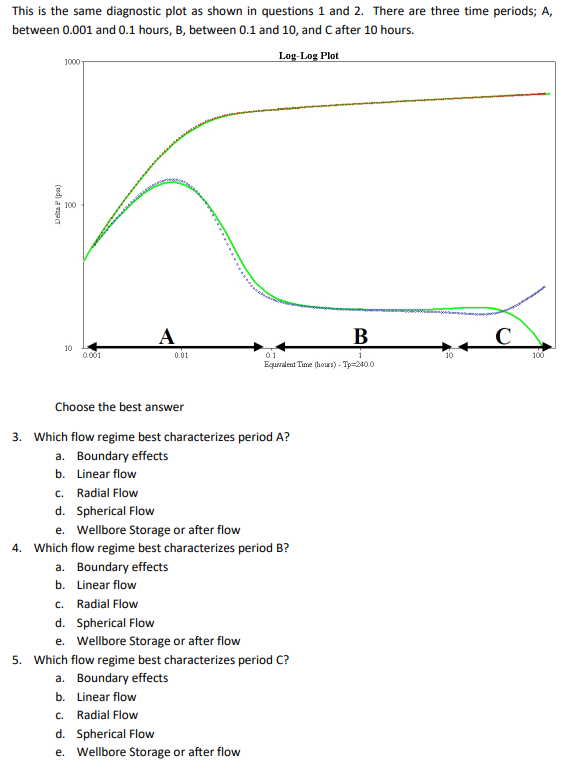




3. e. Wellbore Storage
4. c. Radial Flow
5. a. Boundary Effects

---

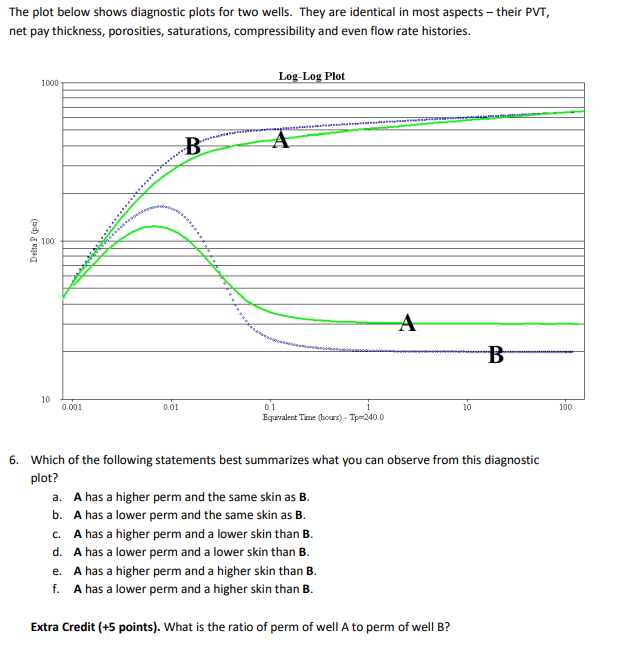

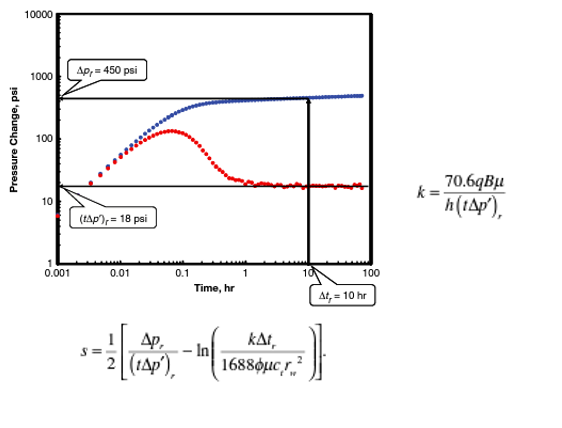

6. d. A has a lower perm and a lower skin than B.

Extra Credit: dPdlogt at well A is 2x Well B therefore Well A has 2x less permeability than Well B

---

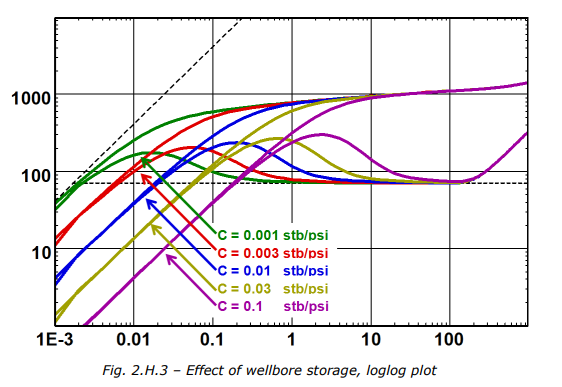

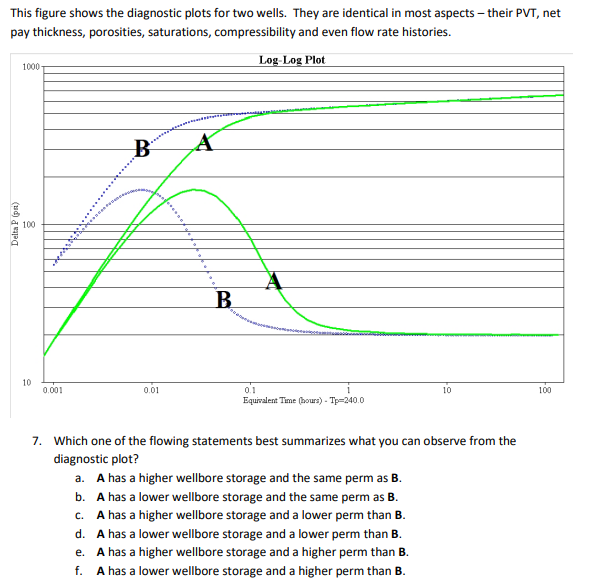

a. A has a higher wellbore storage and the same perm as B.

---

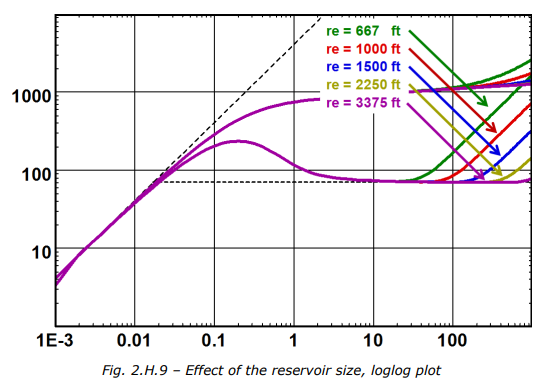


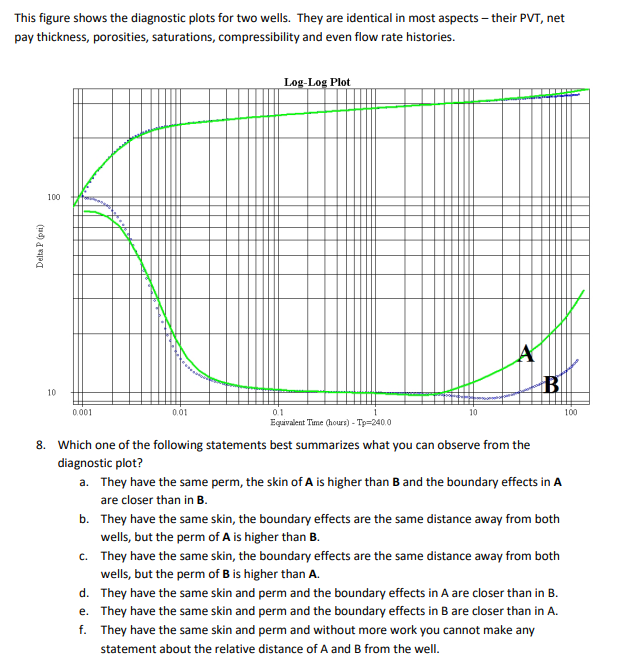

d. They have the same skin and perm and the boundary effects in A are closer than in B.

---
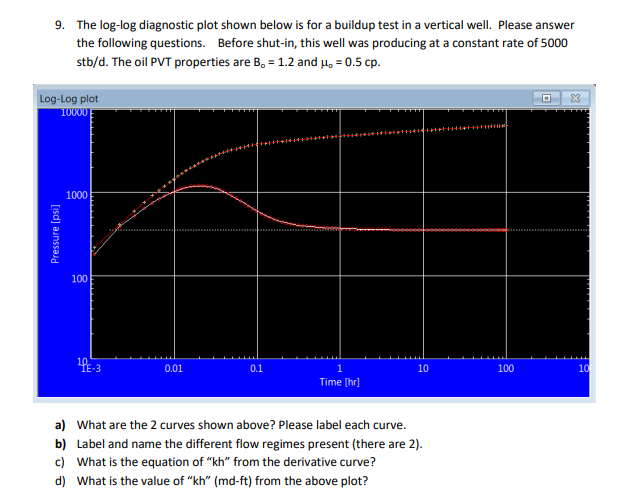

In [9]:
q = 5000 
B = 1.2 
mu = 0.5 
dpdlogt = 330 # halfway on a log scale is 1/3 

kh = 70.6 * q * B * mu / dpdlogt 
print(f"kh = {kh:.0f} md-ft")

kh = 642 md-ft


a. Top Curve is the delta P curve and the bottom curve is the dPdlogt curve  
b. 0-0.3 Time is wellbore storage effects and after this time is infinite acting radial flow  

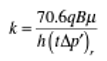 

c. kh = 70.6 * q * Bo * mu / dpdlogt  
d. 642 md-ft



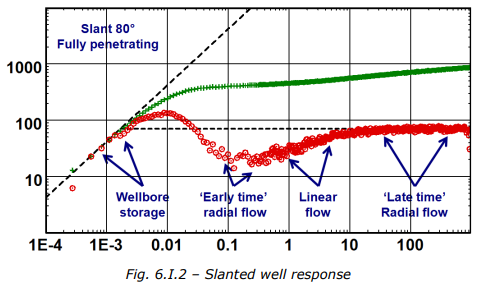

---

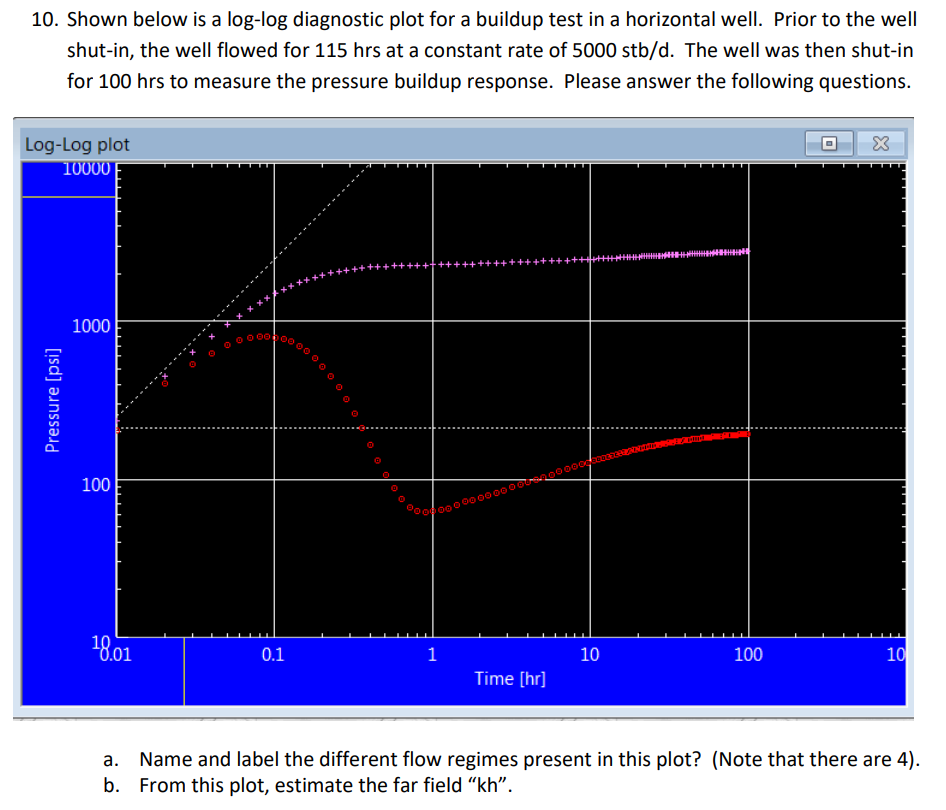


a. 
- 0-0.8 Time : Wellbore Storage
- 0.8-1 Time : Early Time RF
- 1-90 Time : Linear Flow
- 90-100 Time : Late Time Radial Flow  

b.   
assuming same PVT as Q9:  
farfield kh = 642 md-ft

In [10]:
dpdlogt_farfield = 200 
q = 5000 
kh = 70.6 * q * B * mu / dpdlogt 
print(f"kh = {kh:.0f} md-ft")

kh = 642 md-ft


---
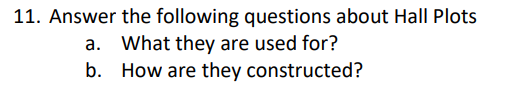


a. Hall Plots are used for monitoring injector health over time.   
b. Hall plots are constructed by plotting Well Head Pressure x Time vs Cum. Injection Volume

---

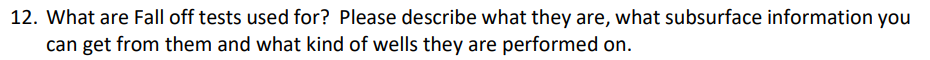


Fall off tests are used for injection-type wells. The pressure fall-off test is analagous to the pressure build-up test used in production-type wells; therefore, the equations for production well testing apply to injection well testing as long as sign conversions are observed. Thus, the same information from build-up tests such as permeability, skin, Pi (in an infinite acting system), etc. can be obtained. 

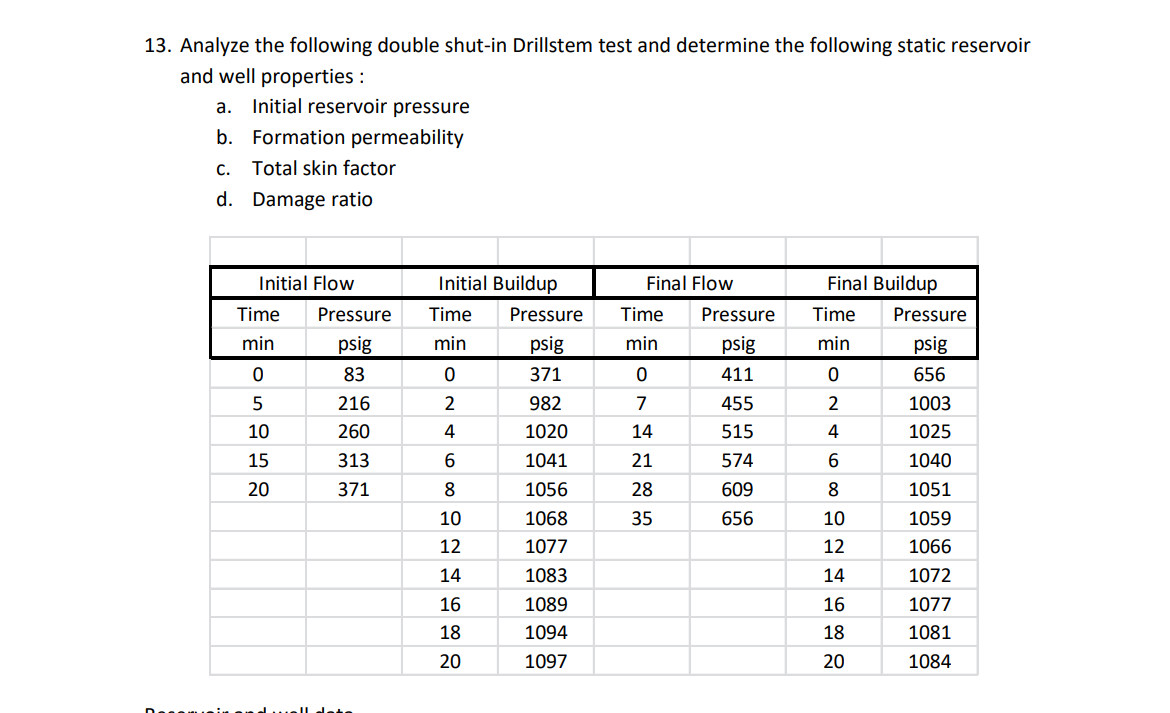

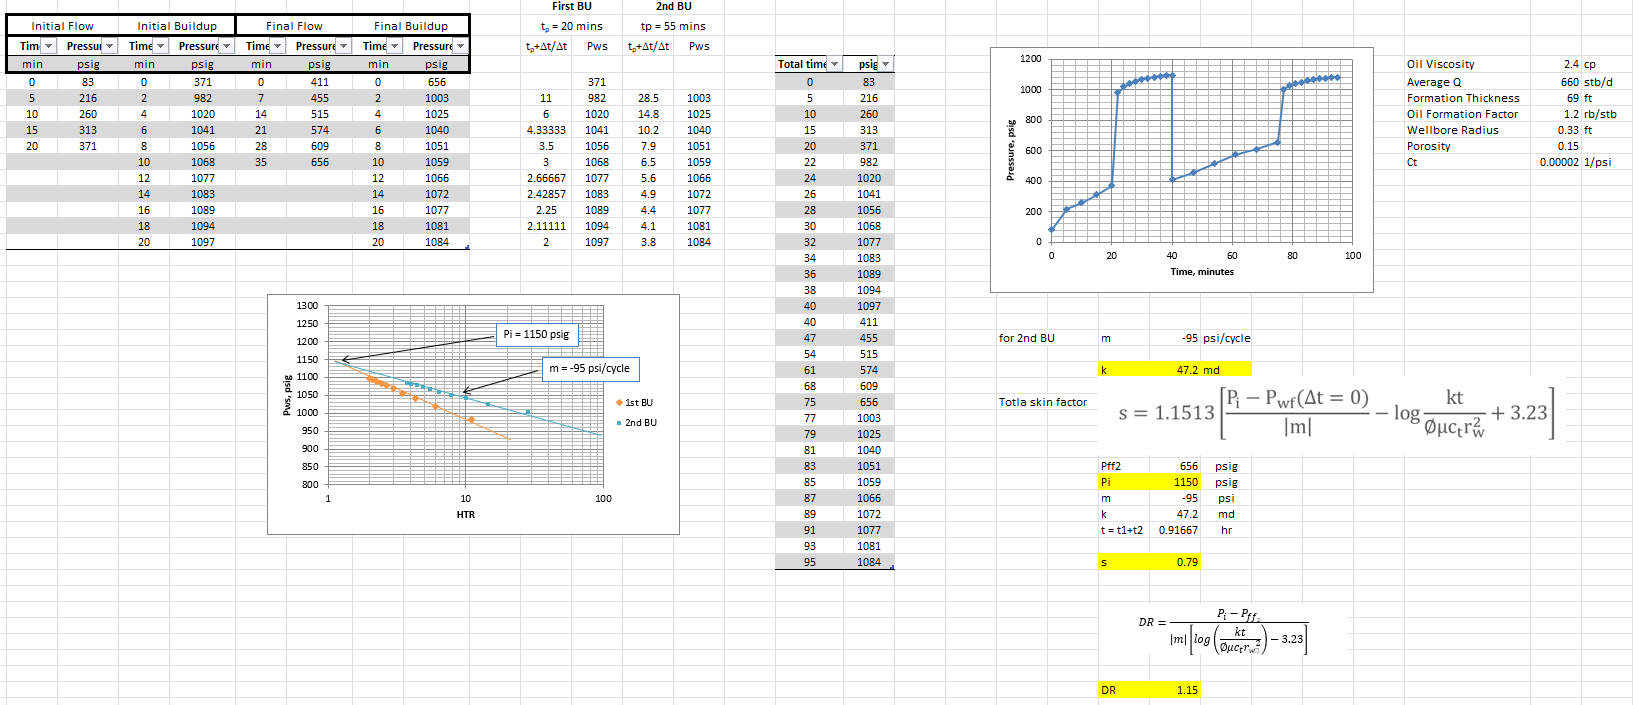

---

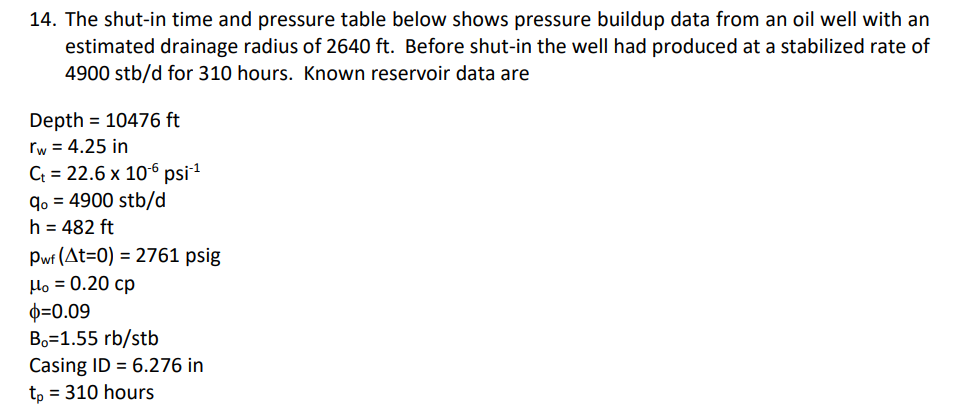

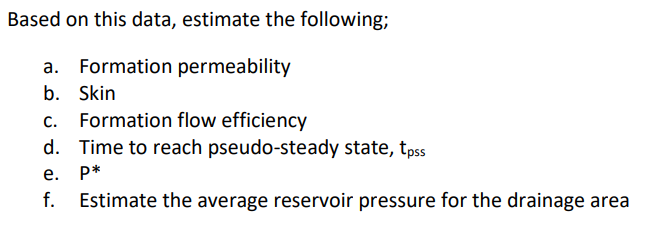

In [11]:
import pandas as pd
import numpy as np

data = {
    "Delta_t_hours": [
        0, 0.1, 0.21, 0.31, 0.52, 0.63, 0.73, 0.84, 0.94, 1.05,
        1.15, 1.36, 1.68, 1.99, 2.51, 3.04, 3.46, 4.08, 5.03, 5.97,
        6.07, 7.01, 8.06, 9.00, 10.05, 13.09, 16.02, 20.00, 26.07,
        31.03, 34.98, 37.54
    ],
    "P_ws_psig": [
        2761, 3057, 3153, 3234, 3249, 3256, 3260, 3263, 3266, 3267,
        3268, 3271, 3274, 3276, 3280, 3283, 3286, 3289, 3293, 3297,
        3297, 3300, 3303, 3305, 3306, 3310, 3313, 3317, 3320,
        3322, 3323, 3323
    ]
}

df = pd.DataFrame(data)
df["Delta_t_hours"] = df["Delta_t_hours"] + 310 
pi = 2761 
t = np.linspace(1, 310, 100)
p = np.ones_like(t) * pi
dict_prod = {"Delta_t_hours": t, "P_ws_psig": p}
df_prod = pd.DataFrame(dict_prod)
df = pd.concat([df_prod, df], ignore_index=True)
df.to_excel("midterm_data.xlsx", index=False)

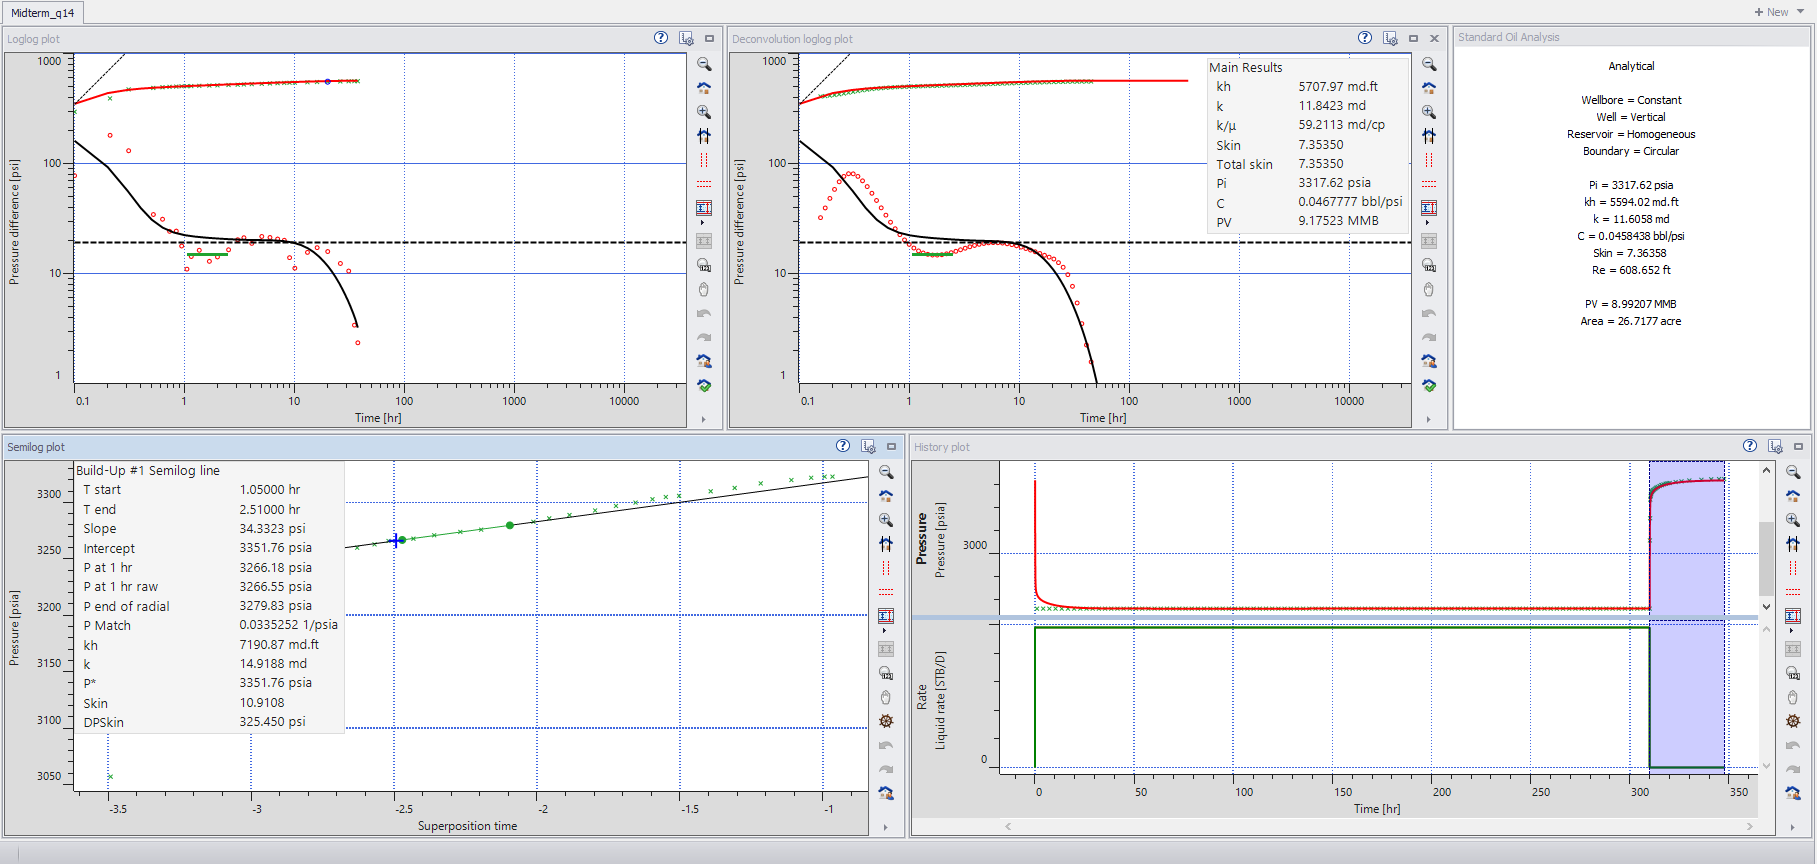

Deconvolution looks suspicously like this class example: 

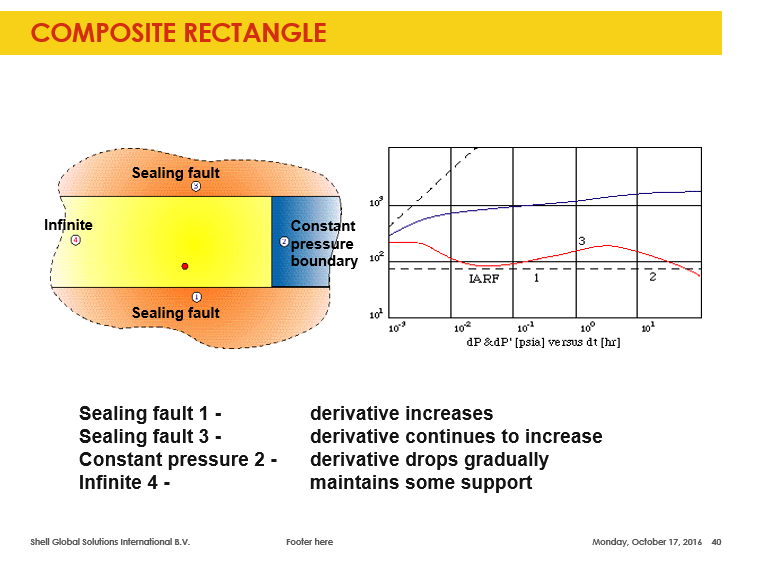

Therefore the decision was made to do horner analysis based on the first IARF period instead of the doubled region after

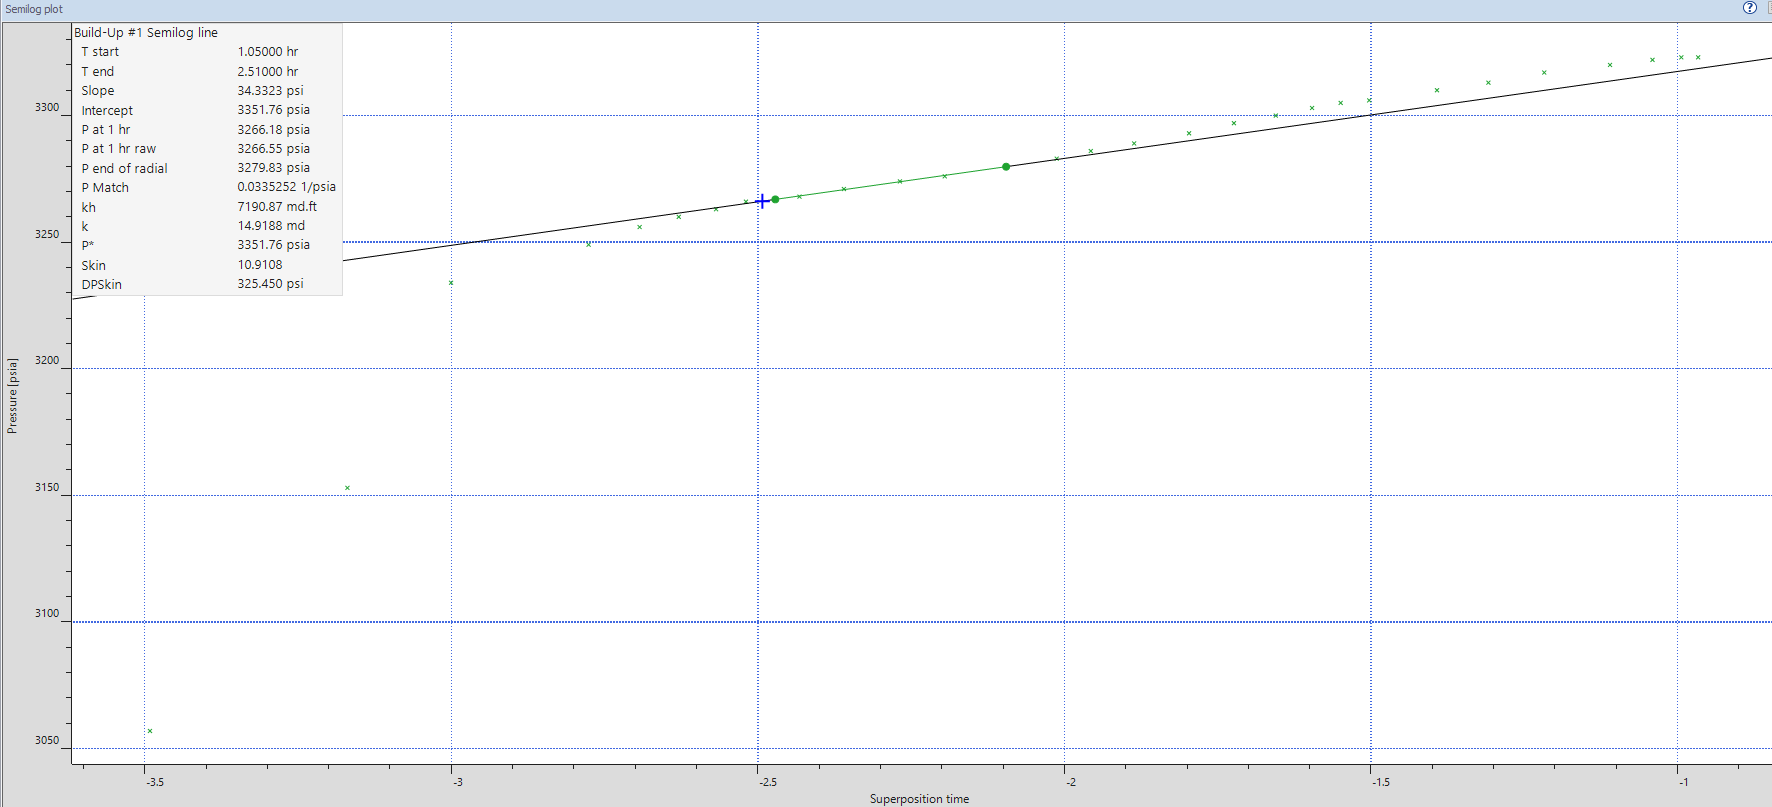

giving results of 
- k = 14.9 md
- Skin = 10.9
- P* = 3351 psi 

And average reservoir pressure given by Saphir PSS calculator: 

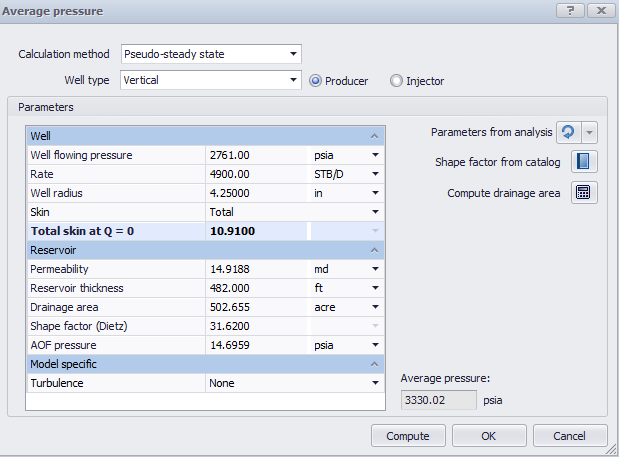

Flow Efficency is calculated from: 

![alt text](IMG_3042.jpeg)


PSS

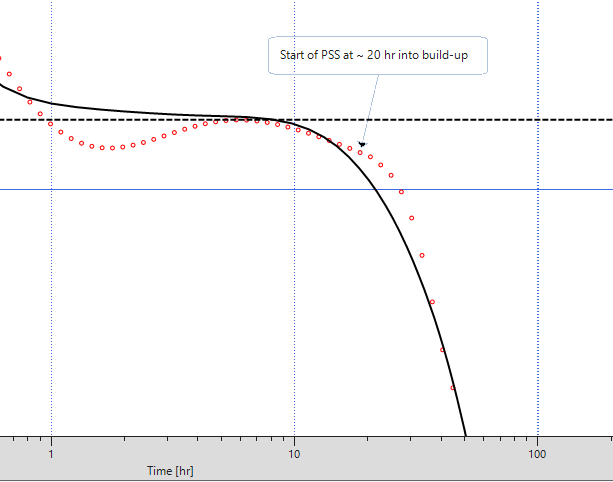

In [12]:
avgP = 3330.02 # psi 
deltaPskin = 325.45 # psi 
def FlowEfficency(avgP,dPskin,pwf):
    p_pwf = avgP - pwf
    return (p_pwf - dPskin) / p_pwf
FE = FlowEfficency(avgP, deltaPskin, 2761)
print(f"Flow Efficiency = {FE:.2%}")

Flow Efficiency = 42.81%


Summary of Results:  
a. Formation permeability = 14.9 mD  
b. Skin = 10.9  
c. Formation flow efficiency = 42.81%  
d. Time to reach pseudo-steady state, tpss = ~20 hrs  
e. P* = 3351  
f. Estimate the average reservoir pressure for the drainage area = 3330 psi  

---
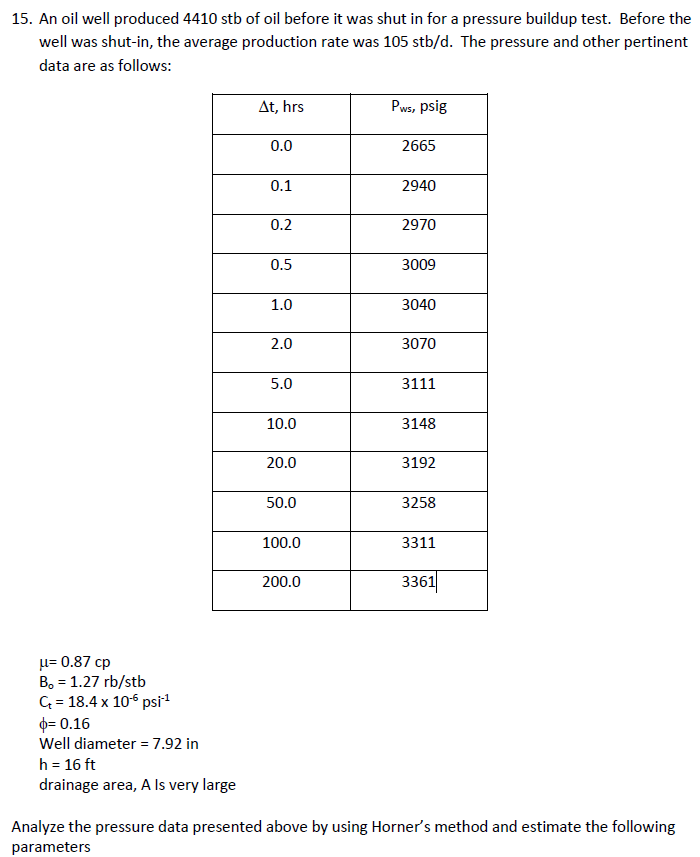

Analyze the pressure data presented above by using Horner’s method and estimate the following parameters  
a. Formation permeability  
b. Total skin factor  
c. Average reservoir pressure  
d. Any other parameter you think is appropriate in view of the data from the trend then please explain.


In [13]:
data = {
    "Delta_t_hrs": [0.0, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0],
    "P_ws_psig": [2665, 2940, 2970, 3009, 3040, 3070, 3111, 3148, 3192, 3258, 3311, 3361]
}

df = pd.DataFrame(data)

pi = 2665
vol_prod = 4410 # stb
q_avg = 105 # stb/d 
effective_prod_time_days = vol_prod / q_avg
effective_prod_time_hrs = effective_prod_time_days * 24

prod_t = np.linspace(0, effective_prod_time_hrs, 100)
prod_p = np.ones_like(prod_t) * pi
df_prod = pd.DataFrame({"Delta_t_hrs": prod_t, "P_ws_psig": prod_p})

df["Delta_t_hrs"] = df["Delta_t_hrs"] + effective_prod_time_hrs
df = pd.concat([df_prod, df], ignore_index=True)

df.to_excel("midterm_data_2.xlsx", index=False)
print(f"effective flowing time = {effective_prod_time_days:.2f} days")
print(f"effective flowing time = {effective_prod_time_hrs:.2f} hours")

effective flowing time = 42.00 days
effective flowing time = 1008.00 hours


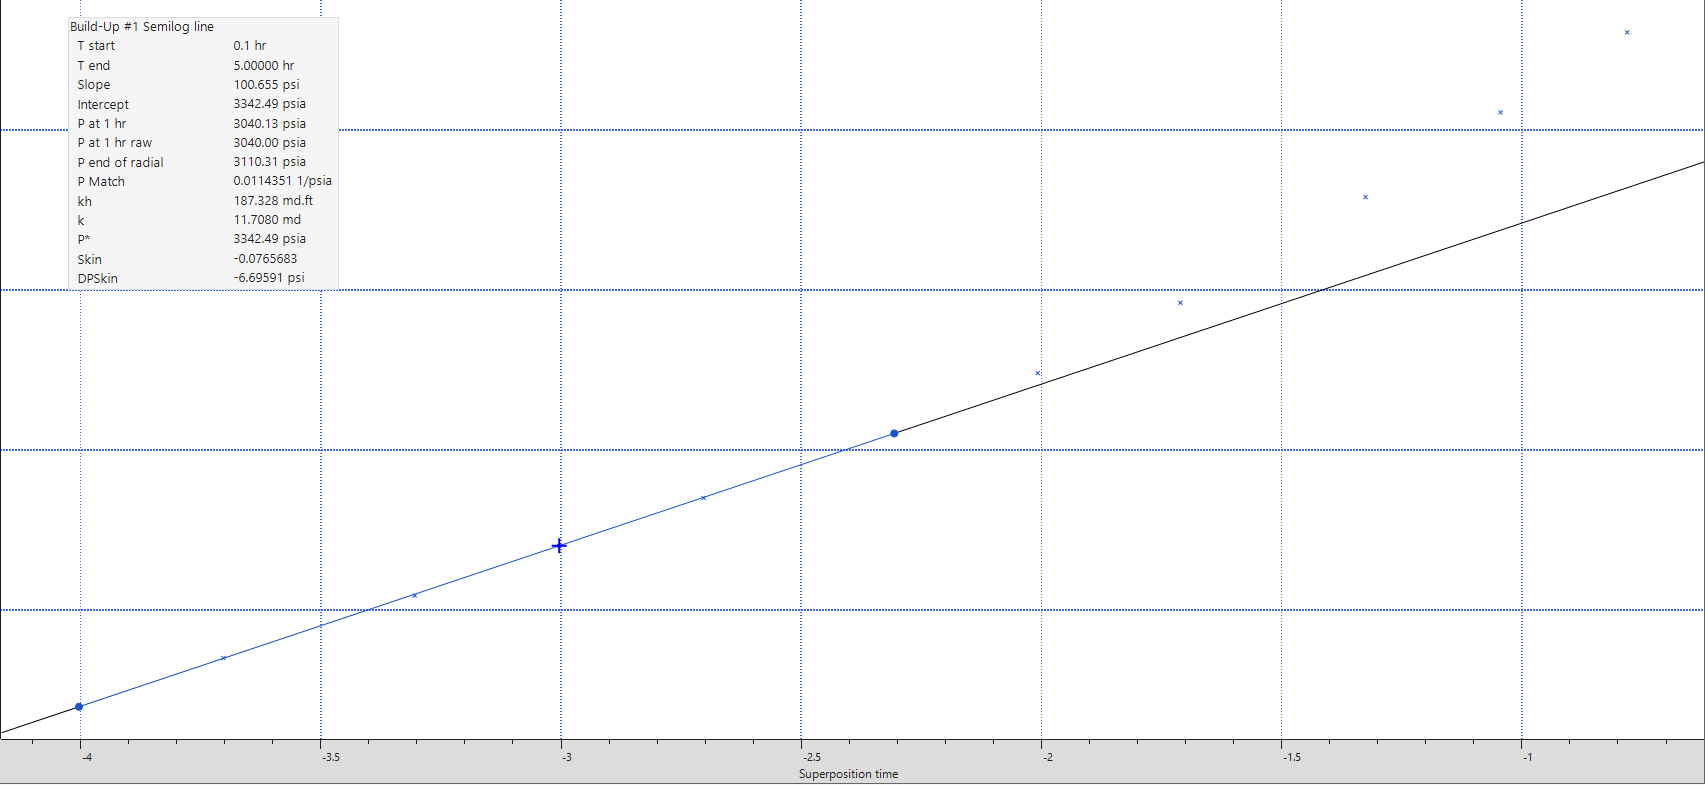

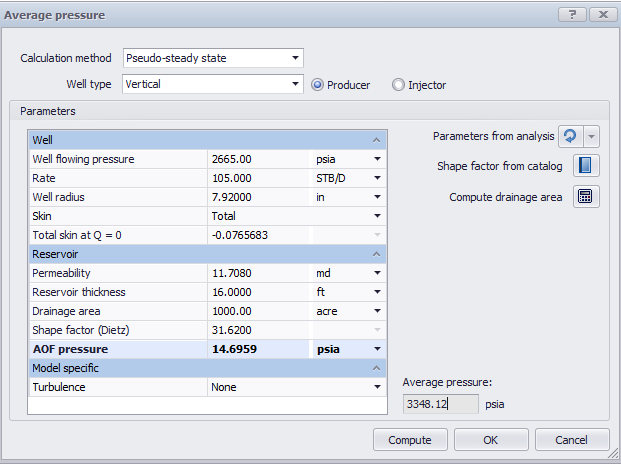

Permeability = 11.708 mD  
Skin = -0.076  
Average Reservoir Pressure = 3348.12 psi   
Other relevant paramters might include C the wellbore storage coefficent. Saphir estimated this value to be equal to 4.62931E-4 bbl/psi 

---

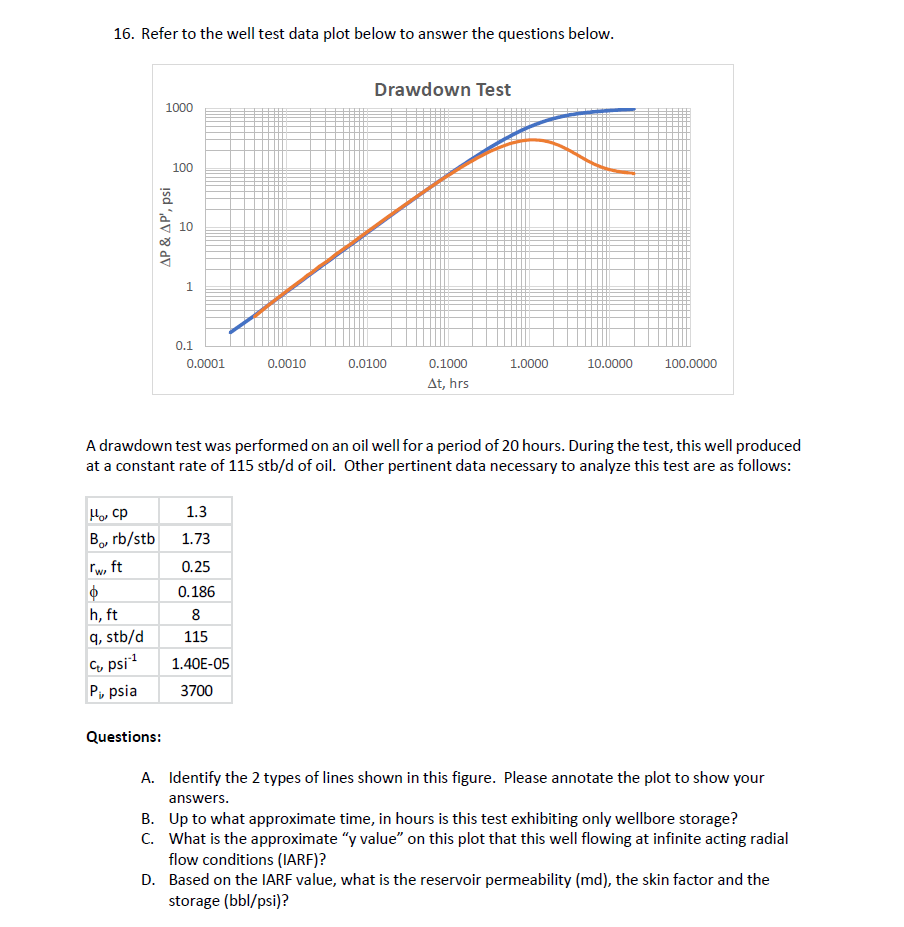

In [14]:
q = 115
B = 1.73 
mu = 1.3 
dpdlogt = 80  

kh = 70.6 * q * B * mu / dpdlogt 
print(f"kh = {kh:.0f} md-ft")

h = 8 
k = kh / h
print(f"k = {k:.0f} md")

kh = 228 md-ft
k = 29 md


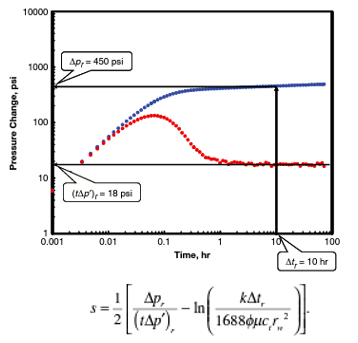


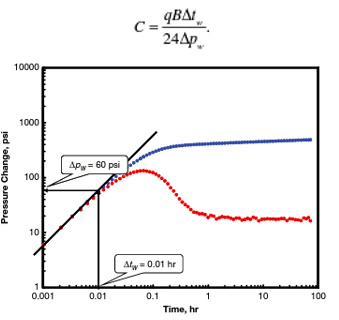

In [15]:
dp = 1000 # psi 
dt = 20 # hr 
phi = 0.186
mu = 1.3 # cp
ct = 1.4E-5 # 1/psi
rw = 0.25 # ft

dp_dpdlogt = dp / dpdlogt
s = 0.5 * (dp_dpdlogt - np.log( (k*dt) / (1688 * phi * mu * ct * rw**2) ))
print(f"s = {s:.2f}")


s = -0.89


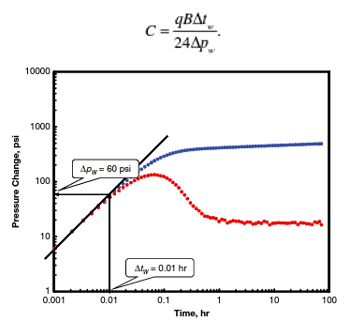

In [16]:
dtw = 0.1 # hr
dpw = 100 # psi 

C = q * B * dtw / 24 / dpw
print(f"C = {C:.5f} bbl/psi")

C = 0.00829 bbl/psi


16 Summary of results: 
a.  
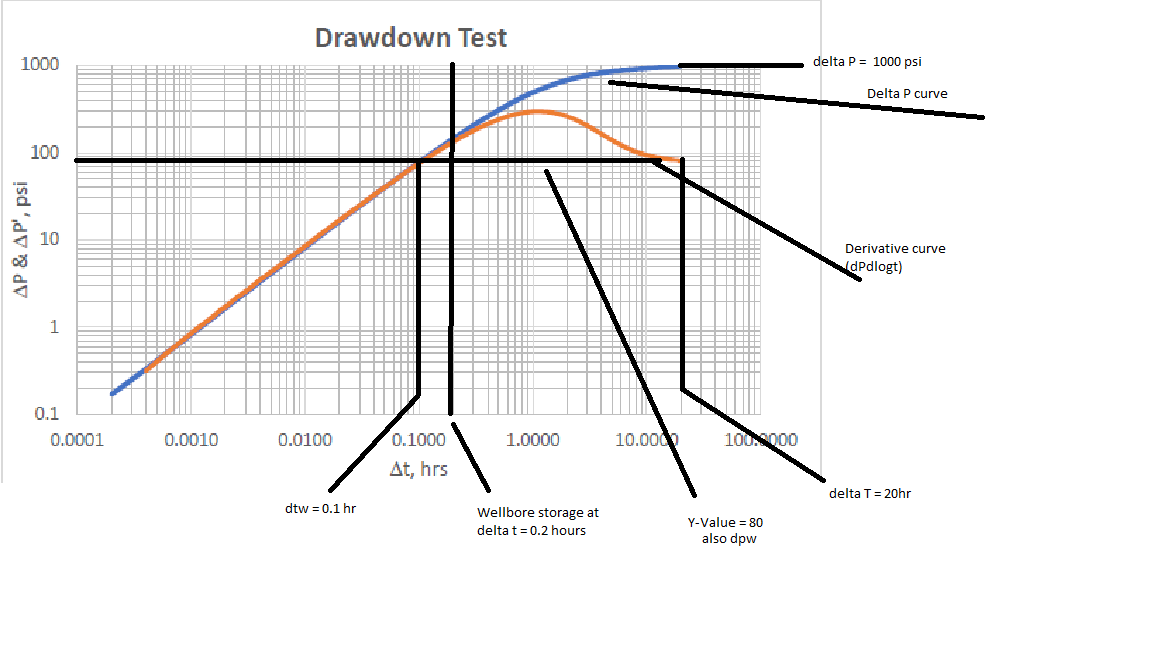

b.  
- 0.1-0.2 hrs  

c.  
- y value = 80

d. 
- k = 29 md
- s = -0.89
- C = 0.00829 bbl/psi

--- 
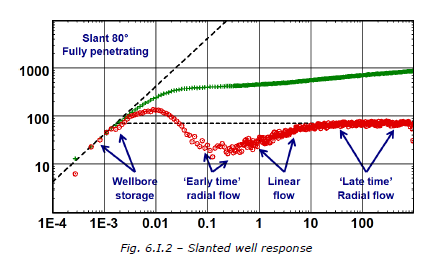


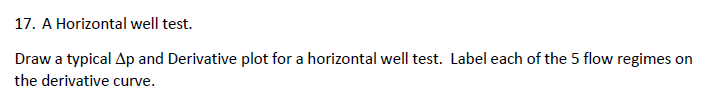

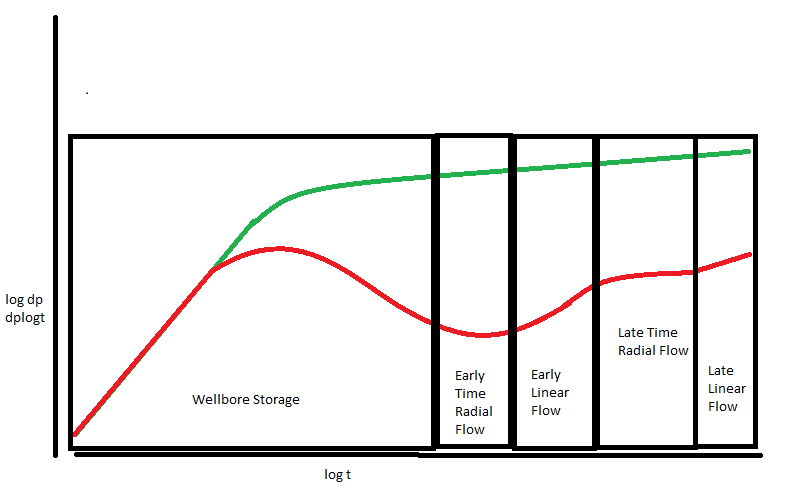

Wellbore Storage, ERF, Linear Flow, Late time radial flow, late linear flow